In [1]:
from sklearn.datasets import load_iris
from utils import ruin_data
import pandas as pd
import seaborn as sns

Scikit-learn offers some toy datasets. For this notebook, we will use the iris dataset, which can be loaded as follows:

In [2]:
data, targets = load_iris(return_X_y=True, as_frame=True)

### Brief excursus on obtaining datasets
scikit learn offers some convenient way to access the datasets hosted at the openml.org dataset repository (can be searched [here](https://www.openml.org/search?type=data&sort=runs&status=active))

```python
from sklearn.datasets import fetch_openml

data_openml = fetch_openml(name='soybean', version=1) # by name
data_openml = fetch_openml(data_id=42) # or by id
```

In many cases, datasets are provided as DataFrames

In [4]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
targets

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

# Preprocessing
Before we analyse the data, it is crucial to inspect it. 
In this case, we know it is "clean", but with real-life data it may not be the case.
So, we can introduce some issues in the data :)

In [6]:
data = ruin_data(data)
data["target"] = targets


## Check for missing values
Some data points may be missing from the dataset. 

In [7]:
data.iloc
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,147.000000,150.000000,150.000000,150.000000,150.000000
mean,5.852381,69.702667,3.758000,1.199333,1.000000
std,0.830855,816.247145,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.375000,5.100000,1.800000,2.000000
max,7.900000,10000.000000,6.900000,2.500000,2.000000


Looking at the counts, it seems like this is the case. You can choose to (depending on the situation):
- remove the rows where data is missing
- replace the missing data with the mean of the column
- remove the column where data is missing

In [8]:
data = data.dropna()
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,147.000000,147.000000,147.000000,147.000000,147.000000
mean,5.852381,71.068027,3.764626,1.206122,1.000000
std,0.830855,824.533693,1.765646,0.765186,0.819288
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.400000,1.300000,1.000000
75%,6.400000,3.350000,5.100000,1.800000,2.000000
max,7.900000,10000.000000,6.900000,2.500000,2.000000


## Check for outliers
Outliers can be identified visually and using e.g. z-score or IQR

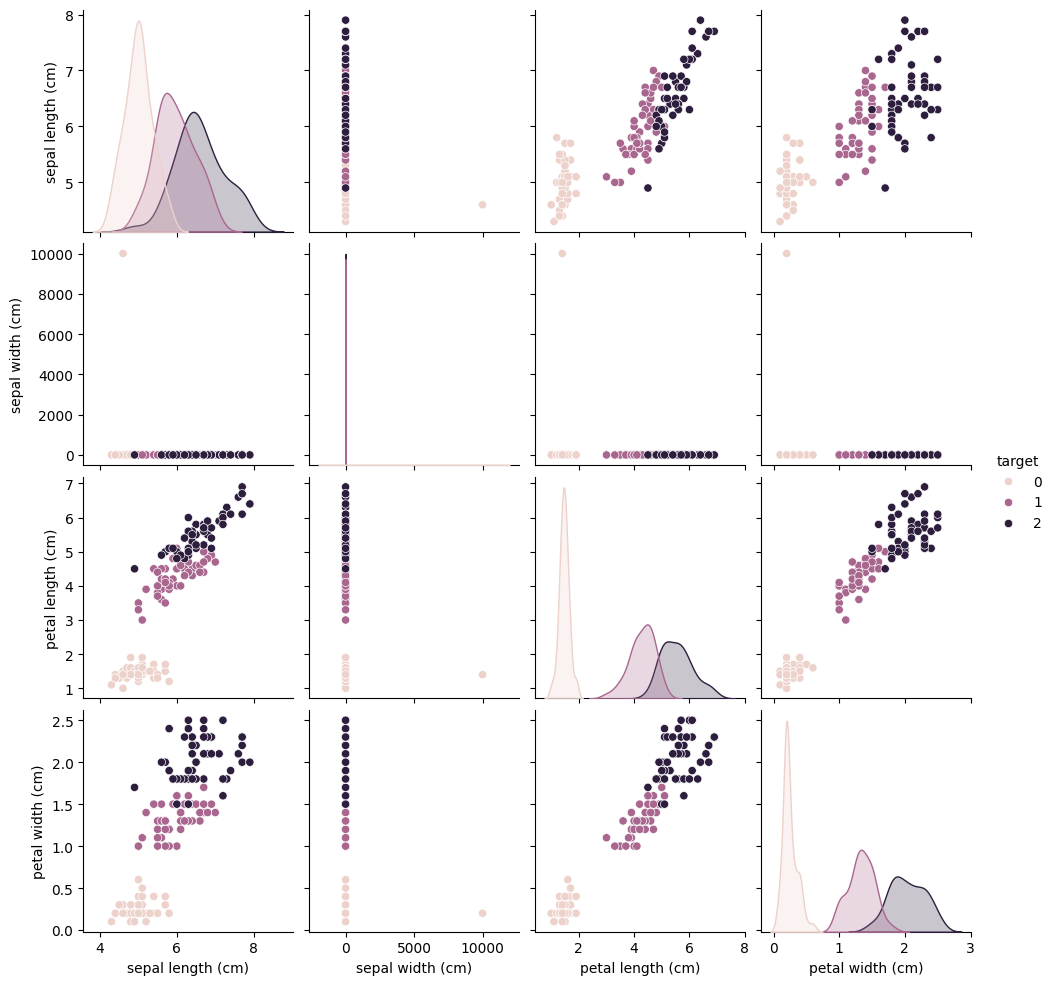

In [9]:
sns.pairplot(data, hue="target")

In [10]:
from scipy.stats import zscore
import numpy as np
zscores = np.abs(zscore(data))

outliers = (zscores > 3.5).any(axis=1)

data = data[~outliers]

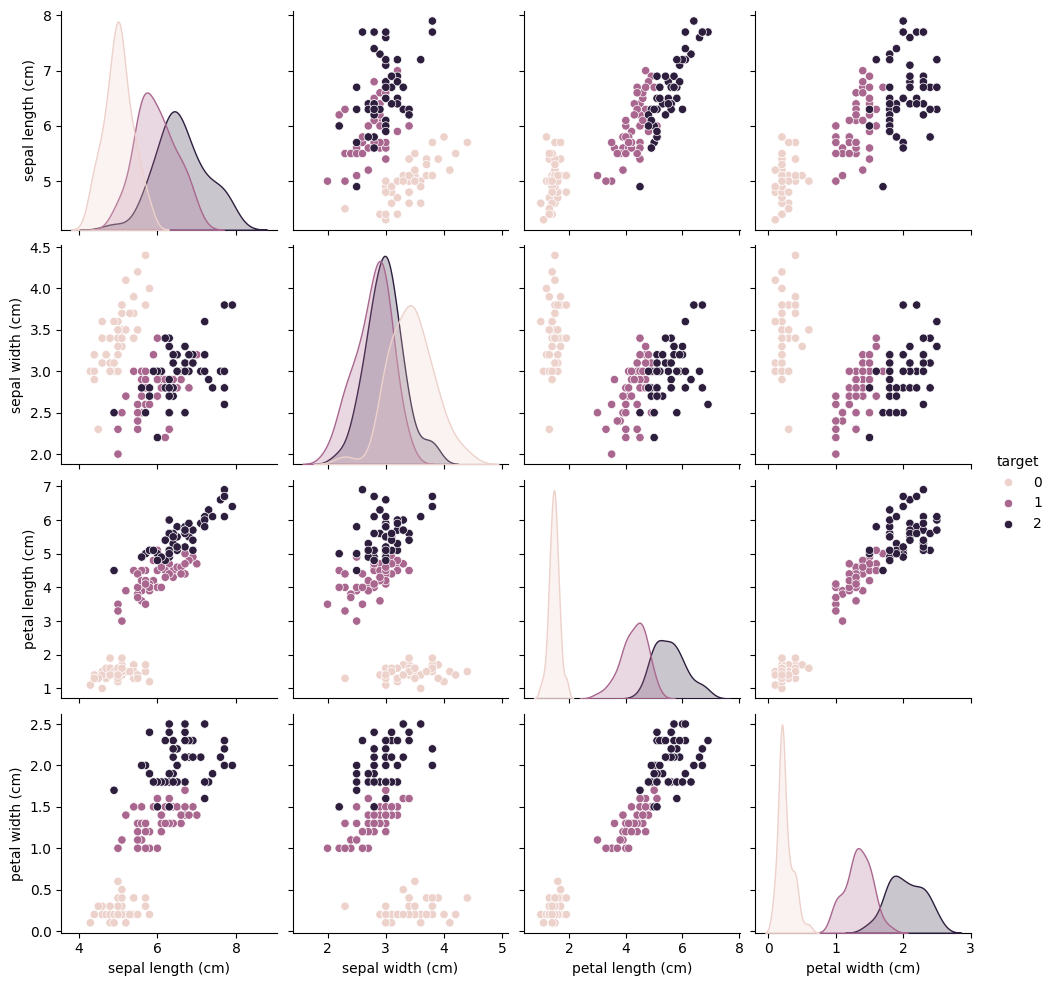

In [11]:
sns.pairplot(data, hue="target")

## Data scaling
Some techniques based on distances can suffer from data having different scales in different dimensions. 

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Apply scaling
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)


# Exploratory analysis

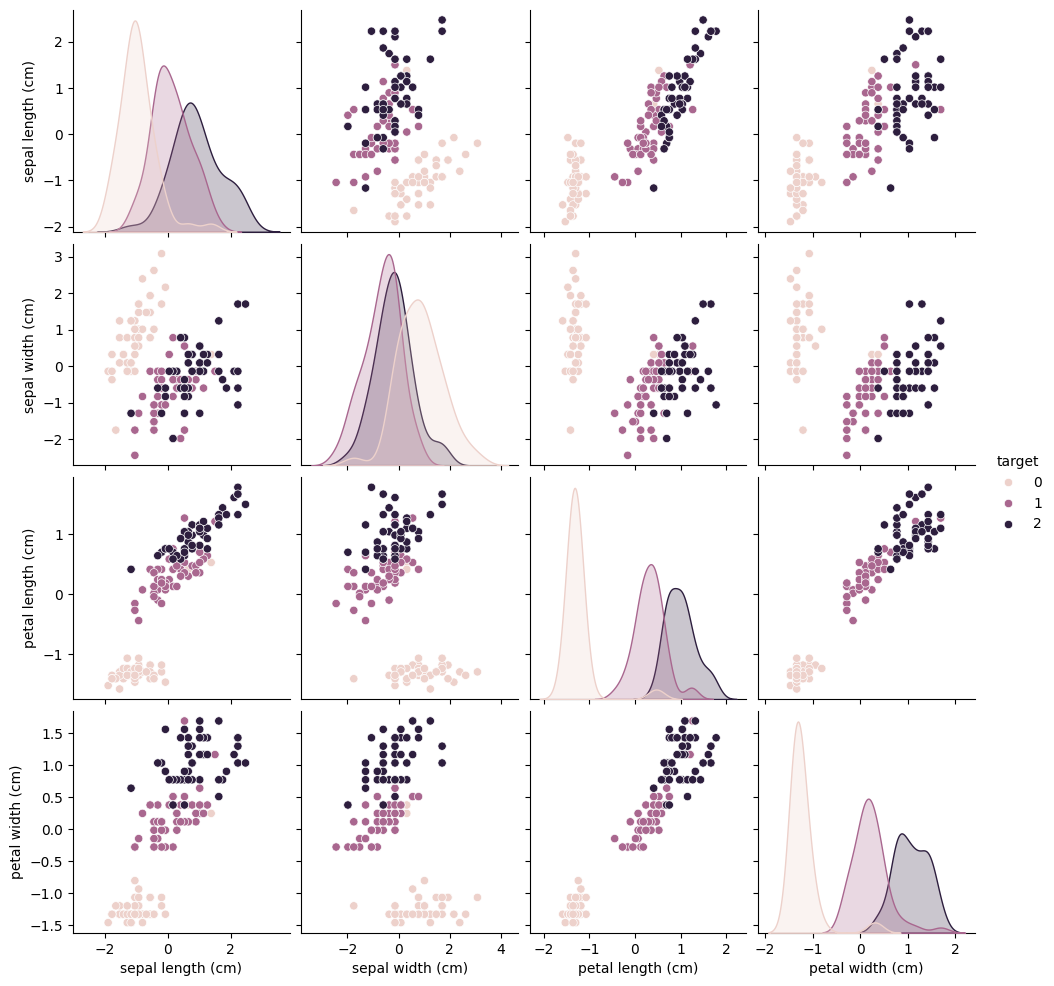

In [13]:
data_scaled["target"] = targets
sns.pairplot(data_scaled, hue="target")

You can plot the correlation matrix between the features using a heatmap together with the `corr` method of a dataframe.

<Axes: >

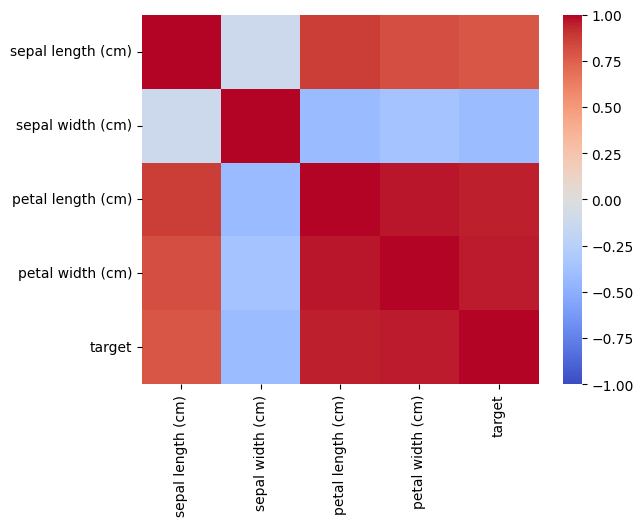

In [14]:
sns.heatmap(data.corr(), vmin=-1, vmax=1, cmap="coolwarm")

Convert the data to numpy format (use `to_numpy()` method) and save it (use `np.save()`)

In [15]:
X = data.to_numpy()

In [16]:
y = X[:,-1]
X = X[:,0:-1]

In [17]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.2],
       [5. , 3

In [18]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [19]:
np.save("X", X)
np.save("y", y)